In [4]:
# ============================================================
# Crop Recommendation Analysis Using Unsupervised Learning
# ============================================================

# Import Required Libraries

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering

from sklearn.decomposition import PCA

from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score

In [5]:
# Load Dataset

df = pd.read_csv("Crop_recommendation.csv")

# Display first five rows

df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [6]:
print("="*50)
print("Dataset Shape")
print("="*50)
print(df.shape)

print("\n")

print("="*50)
print("Dataset Information")
print("="*50)
df.info()

print("\n")

print("="*50)
print("Statistical Summary")
print("="*50)
display(df.describe())

Dataset Shape
(2200, 8)


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


Statistical Summary


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [7]:
# Missing Values
print("Missing Values")
print(df.isnull().sum())

print("\n")

# Duplicate Records
print("Duplicate Rows :", df.duplicated().sum())

Missing Values
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


Duplicate Rows : 0


In [8]:
print("Number of Crop Types:", df['label'].nunique())
print("\nCrop Names:")
print(df['label'].unique())

Number of Crop Types: 22

Crop Names:
['rice' 'maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'mothbeans'
 'mungbean' 'blackgram' 'lentil' 'pomegranate' 'banana' 'mango' 'grapes'
 'watermelon' 'muskmelon' 'apple' 'orange' 'papaya' 'coconut' 'cotton'
 'jute' 'coffee']


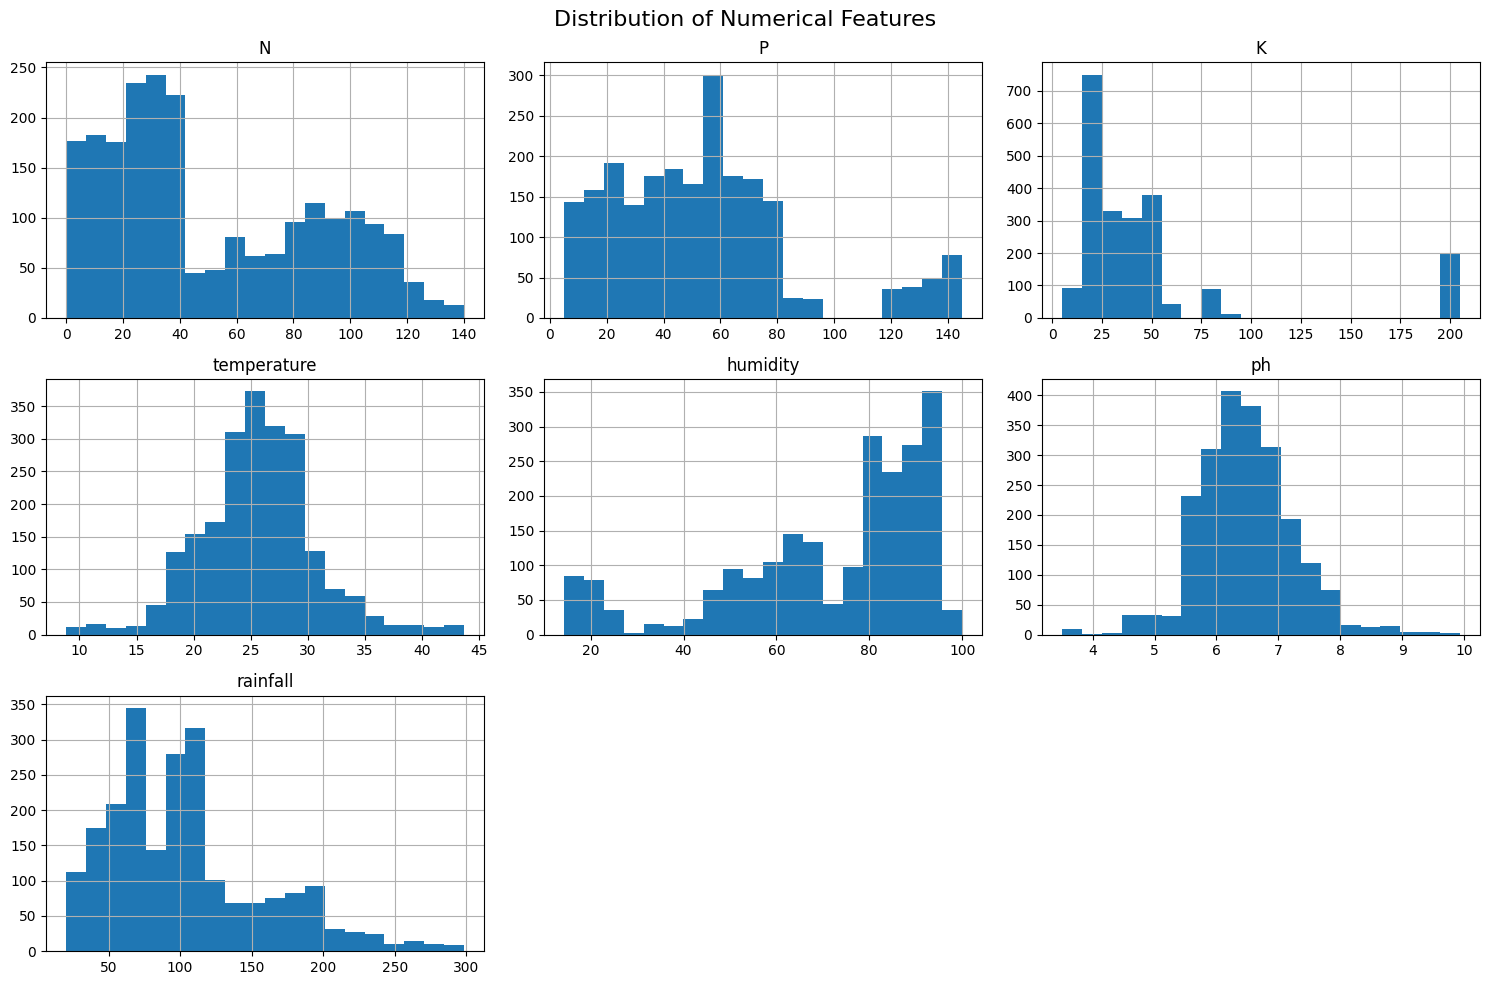

In [9]:
df.hist(figsize=(15,10), bins=20)

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

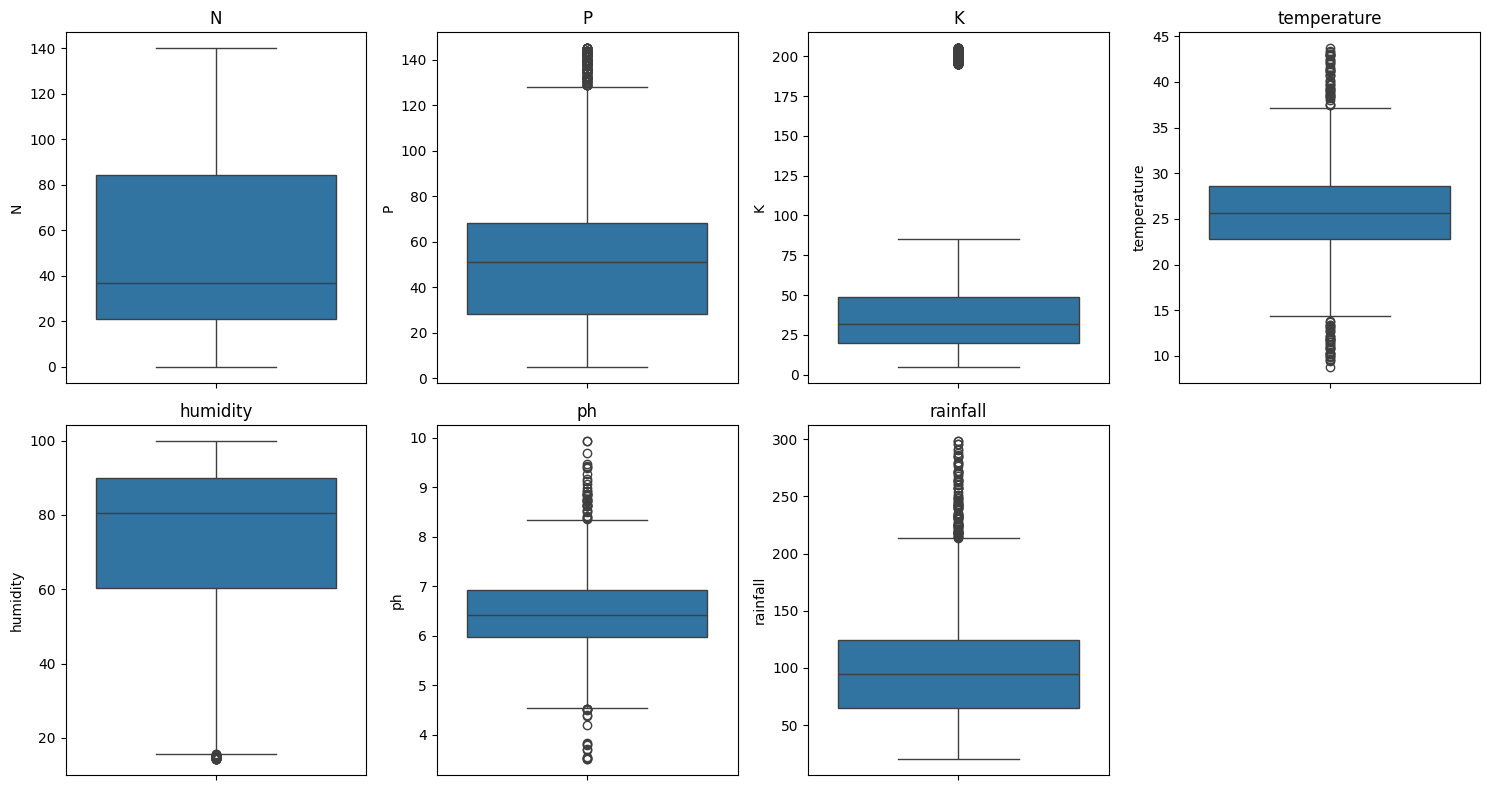

In [10]:
plt.figure(figsize=(15,8))

for i, column in enumerate(df.columns[:-1], 1):
    plt.subplot(2,4,i)
    sns.boxplot(y=df[column])
    plt.title(column)

plt.tight_layout()
plt.show()

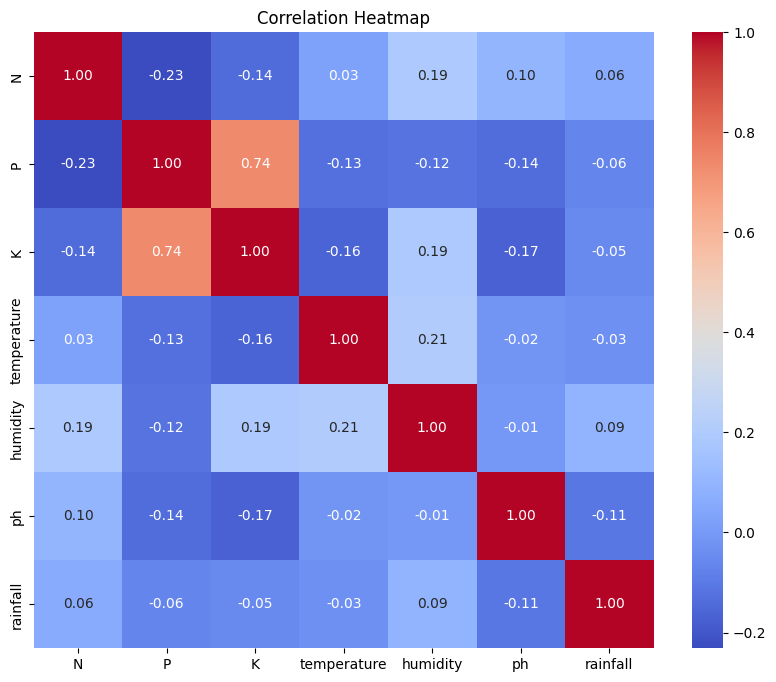

In [11]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.drop('label', axis=1).corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

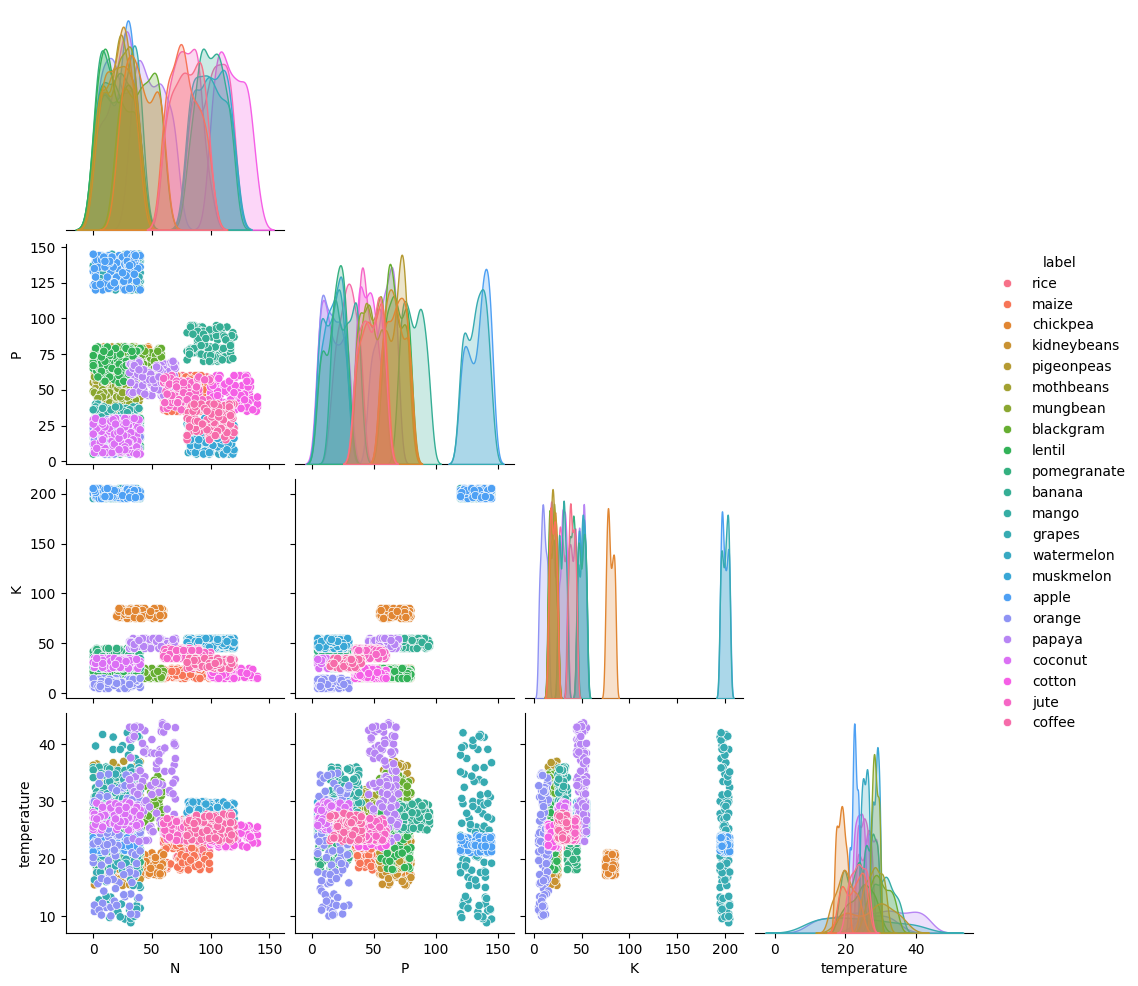

In [12]:
sns.pairplot(
    df,
    vars=['N','P','K','temperature'],
    hue='label',
    corner=True
)

plt.show()

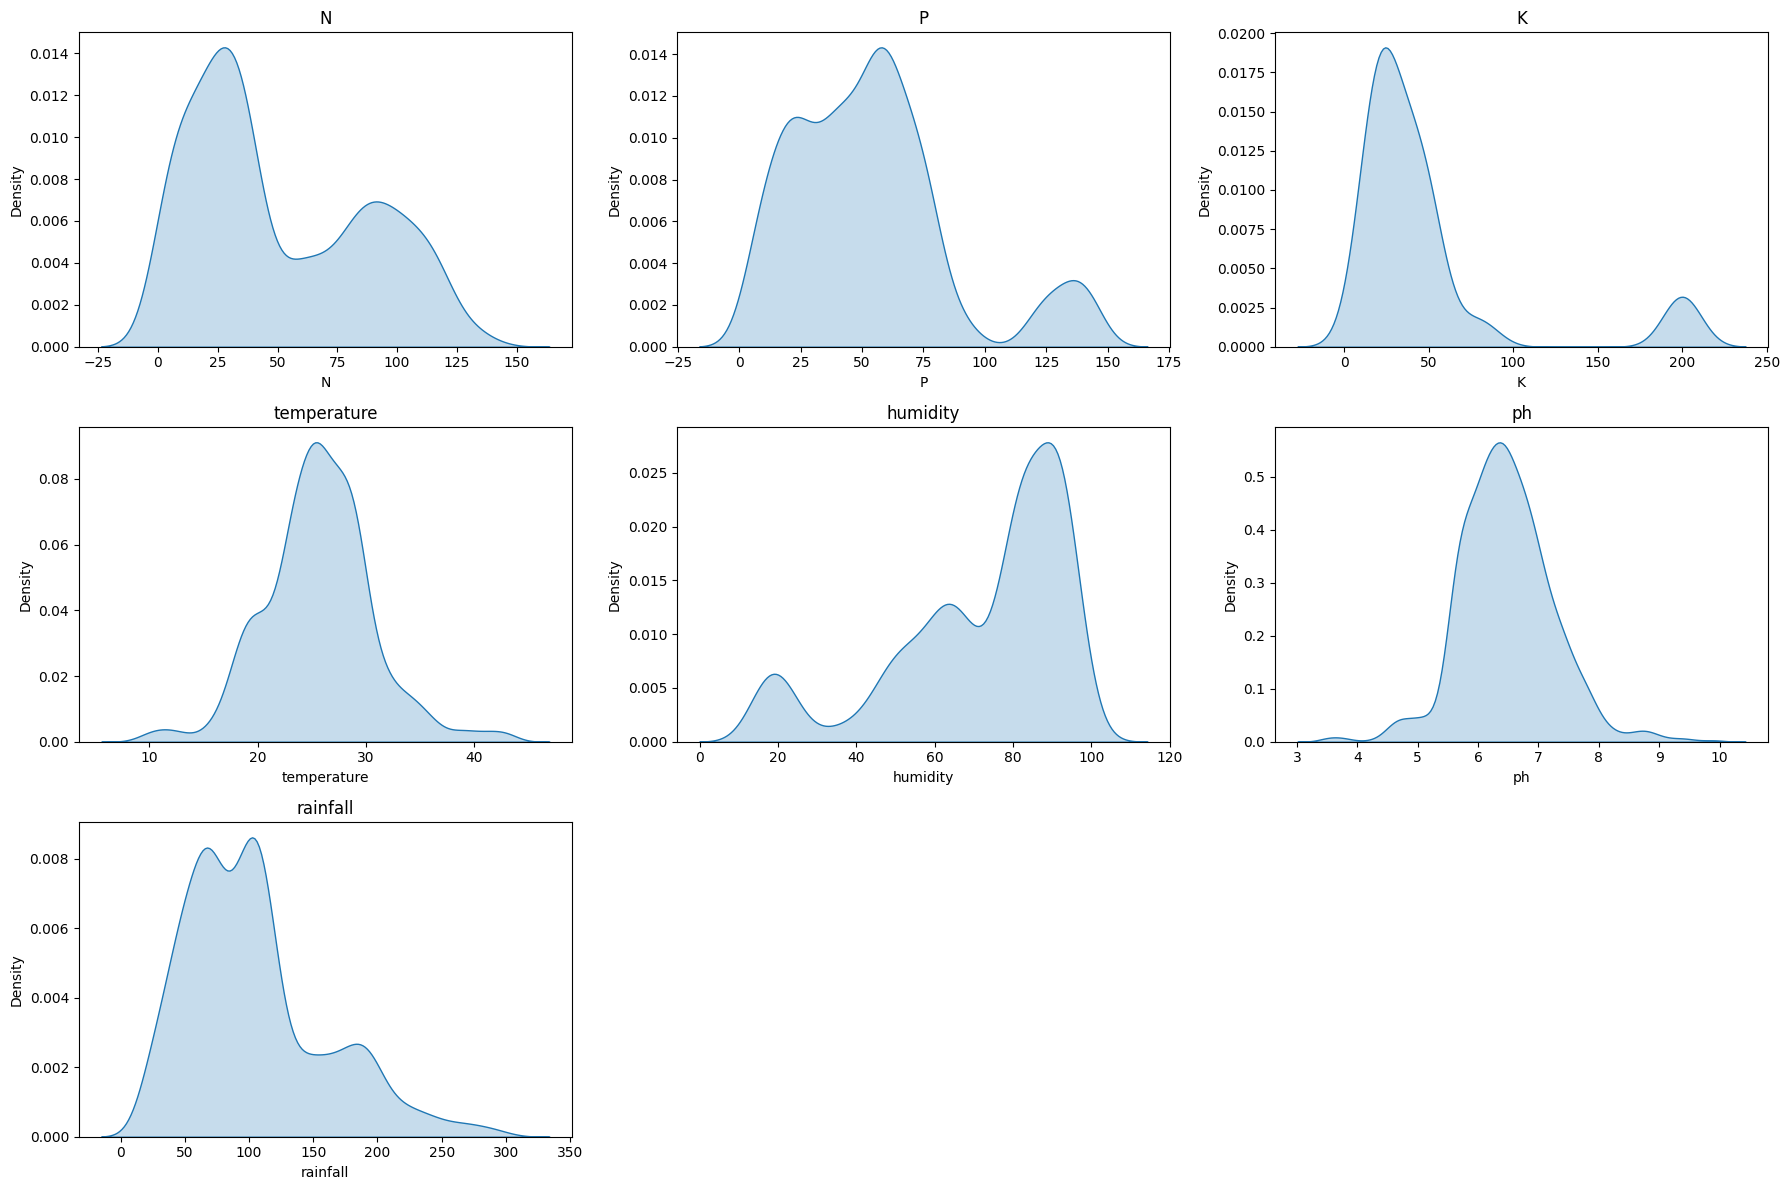

In [13]:
features = ['N','P','K','temperature','humidity','ph','rainfall']

plt.figure(figsize=(18,12))

for i, feature in enumerate(features, 1):
    plt.subplot(3,3,i)
    sns.kdeplot(df[feature], fill=True)
    plt.title(feature)

plt.tight_layout()
plt.show()

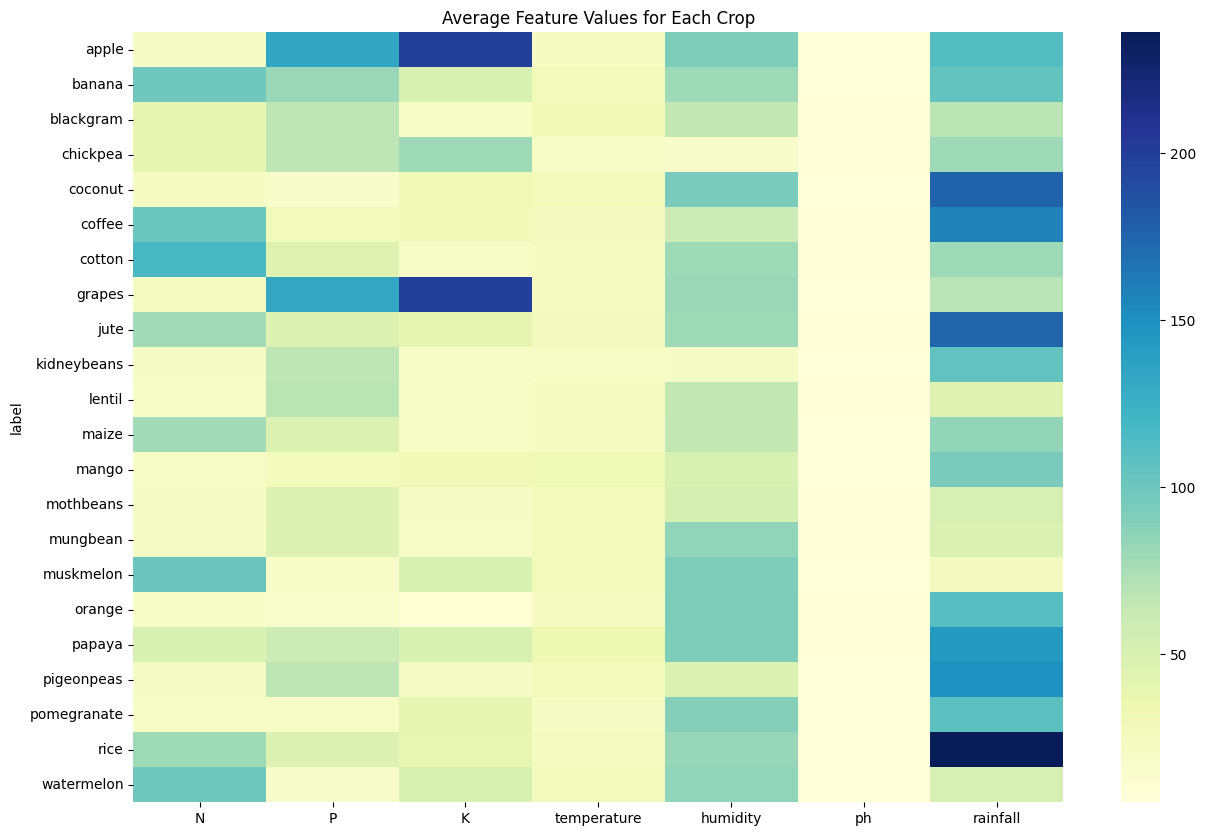

In [14]:
crop_summary = df.groupby('label').mean()

crop_summary.head()
plt.figure(figsize=(15,10))

sns.heatmap(crop_summary, cmap='YlGnBu')

plt.title("Average Feature Values for Each Crop")
plt.show()

In [15]:
# Separate Features and Labels

X = df.drop('label', axis=1)

y = df['label']

print("Features Shape:", X.shape)
print("Labels Shape:", y.shape)

X.head()

Features Shape: (2200, 7)
Labels Shape: (2200,)


,N,P,K,temperature,humidity,ph,rainfall
0,90,42,43,20.879744,82.002744,6.502985,202.935536
1,85,58,41,21.770462,80.319644,7.038096,226.655537
2,60,55,44,23.004459,82.320763,7.840207,263.964248
3,74,35,40,26.491096,80.158363,6.980401,242.864034
4,78,42,42,20.130175,81.604873,7.628473,262.717340


In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled Data Shape:", X_scaled.shape)

Scaled Data Shape: (2200, 7)


In [17]:
scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

scaled_df.head()

,N,P,K,temperature,humidity,ph,rainfall
0,1.068797,-0.344551,-0.101688,-0.935587,0.472666,0.043302,1.810361
1,0.933329,0.140616,-0.141185,-0.759646,0.397051,0.734873,2.242058
2,0.255986,0.049647,-0.081939,-0.515898,0.486954,1.771510,2.921066
3,0.635298,-0.556811,-0.160933,0.172807,0.389805,0.660308,2.537048
4,0.743673,-0.344551,-0.121436,-1.083647,0.454792,1.497868,2.898373


In [18]:
print("Mean of Scaled Features")

print(scaled_df.mean())

print("\n")

print("Standard Deviation")

print(scaled_df.std())

Mean of Scaled Features
N             -1.033517e-16
P              5.167584e-17
K             -5.167584e-17
temperature    3.875688e-16
humidity      -1.808654e-16
ph            -1.291896e-16
rainfall       1.550275e-16
dtype: float64


Standard Deviation
N              1.000227
P              1.000227
K              1.000227
temperature    1.000227
humidity       1.000227
ph             1.000227
rainfall       1.000227
dtype: float64


In [20]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):

    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

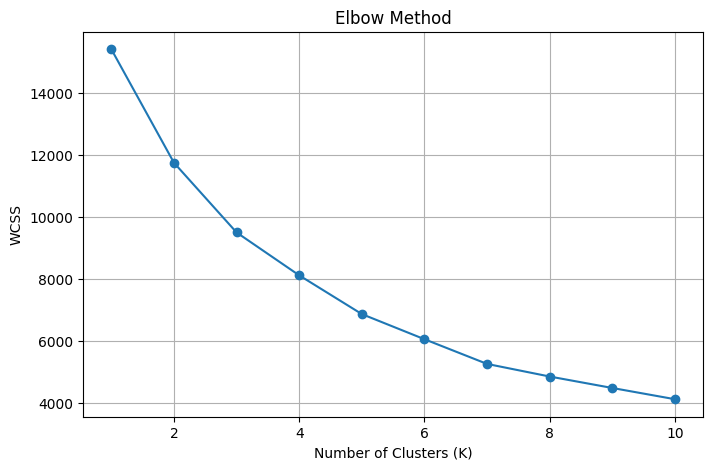

In [21]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters (K)")

plt.ylabel("WCSS")

plt.grid(True)

plt.show()

In [22]:
optimal_k = 4

In [23]:
# Train K-Means Model

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

clusters

array([1, 1, 1, ..., 2, 2, 2], dtype=int32)

In [24]:
# Add Cluster Labels

df['Cluster'] = clusters

df.head()

,N,P,K,temperature,humidity,ph,rainfall,label,Cluster
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,1
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,1
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,1
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,1
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,1


In [25]:
print(df['Cluster'].value_counts().sort_index())

Cluster
0    797
1    618
2    585
3    200
Name: count, dtype: int64


In [26]:
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score

print("Silhouette Score :", silhouette_score(X_scaled, clusters))

print("Davies-Bouldin Index :", davies_bouldin_score(X_scaled, clusters))

print("Calinski-Harabasz Score :", calinski_harabasz_score(X_scaled, clusters))

Silhouette Score : 0.25526916389002857
Davies-Bouldin Index : 1.386621974857969
Calinski-Harabasz Score : 658.6969498661996


In [27]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

pca_df['Cluster'] = clusters

pca_df.head()

,PC1,PC2,Cluster
0,-0.582869,0.844586,1
1,-0.474635,0.784895,1
2,-0.634068,0.694522,1
3,-1.047920,1.087658,1
4,-0.873258,0.658673,1


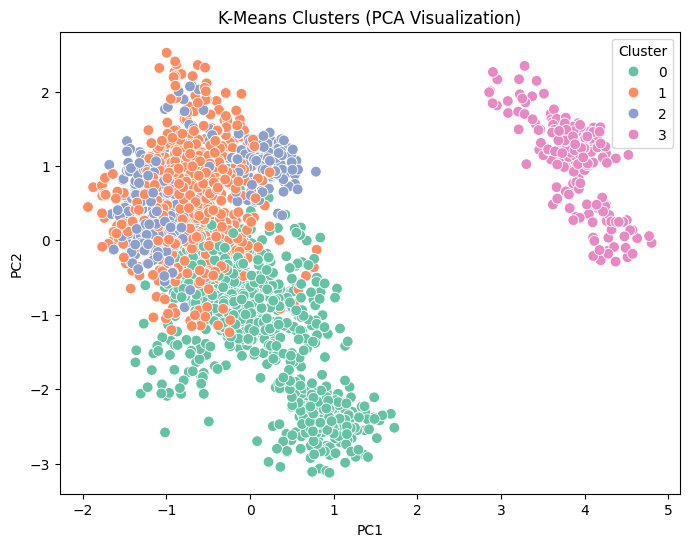

In [28]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set2',
    s=60
)

plt.title("K-Means Clusters (PCA Visualization)")
plt.show()

In [30]:
#TRAIN DBSCAN
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.8,
    min_samples=5
)

db_clusters = dbscan.fit_predict(X_scaled)

db_clusters

array([0, 0, 0, ..., 0, 0, 0])

In [31]:
import numpy as np

print("Unique Clusters:", np.unique(db_clusters))

print("\nCluster Counts")

print(pd.Series(db_clusters).value_counts())

Unique Clusters: [-1  0  1  2  3  4  5  6  7  8  9 10 11]

Cluster Counts
 0     806
 7     546
 10    300
 11    200
-1     108
 4     101
 3     100
 1      11
 5       8
 8       7
 6       6
 9       5
 2       2
Name: count, dtype: int64


In [32]:
# Ignore noise points for evaluation

mask = db_clusters != -1

print("Silhouette Score:",
      silhouette_score(X_scaled[mask], db_clusters[mask]))

print("Davies-Bouldin Index:",
      davies_bouldin_score(X_scaled[mask], db_clusters[mask]))

print("Calinski-Harabasz Score:",
      calinski_harabasz_score(X_scaled[mask], db_clusters[mask]))

Silhouette Score: 0.22899920335558085
Davies-Bouldin Index: 0.9286065441296132
Calinski-Harabasz Score: 288.4481221320182


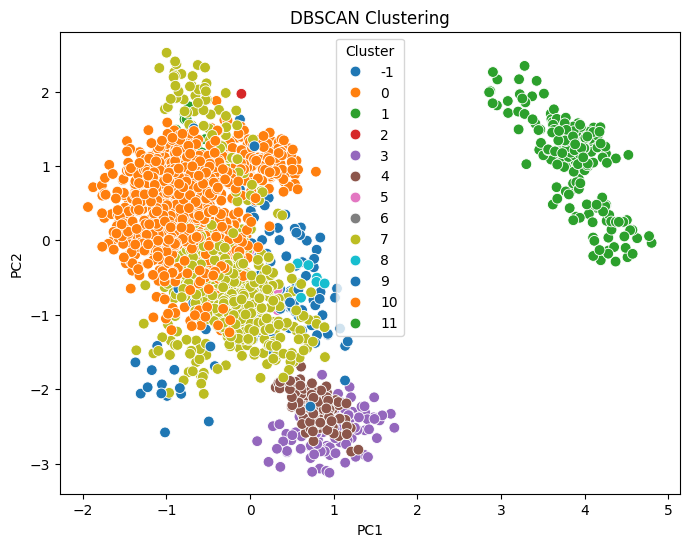

In [33]:
pca_db = pd.DataFrame(X_pca, columns=["PC1","PC2"])

pca_db["Cluster"] = db_clusters

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_db,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab10",
    s=60
)

plt.title("DBSCAN Clustering")
plt.show()

In [34]:
#Train Hierarchical Clustering
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(
    n_clusters=4,
    linkage='ward'
)

hc_clusters = hc.fit_predict(X_scaled)

hc_clusters

array([0, 0, 0, ..., 0, 0, 0])

In [35]:
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score

print("Silhouette Score:",
      silhouette_score(X_scaled, hc_clusters))

print("Davies-Bouldin Index:",
      davies_bouldin_score(X_scaled, hc_clusters))

print("Calinski-Harabasz Score:",
      calinski_harabasz_score(X_scaled, hc_clusters))

Silhouette Score: 0.2592304693088373
Davies-Bouldin Index: 1.426909735115703
Calinski-Harabasz Score: 629.472501911232


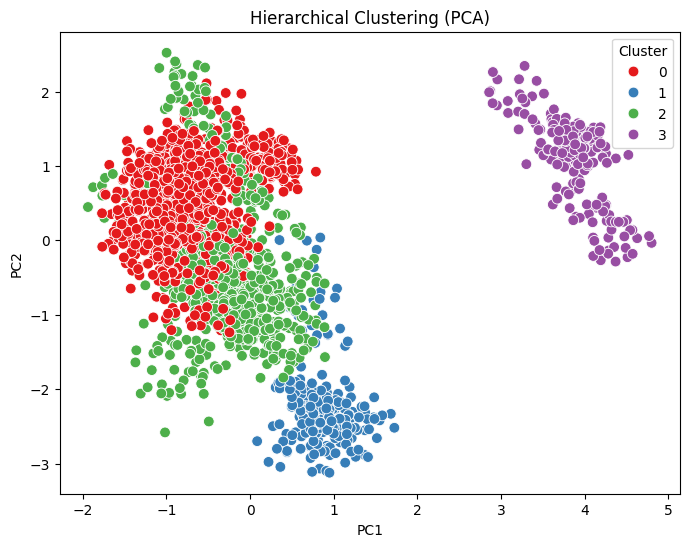

In [36]:
pca_hc = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

pca_hc['Cluster'] = hc_clusters

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_hc,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1',
    s=60
)

plt.title("Hierarchical Clustering (PCA)")
plt.show()

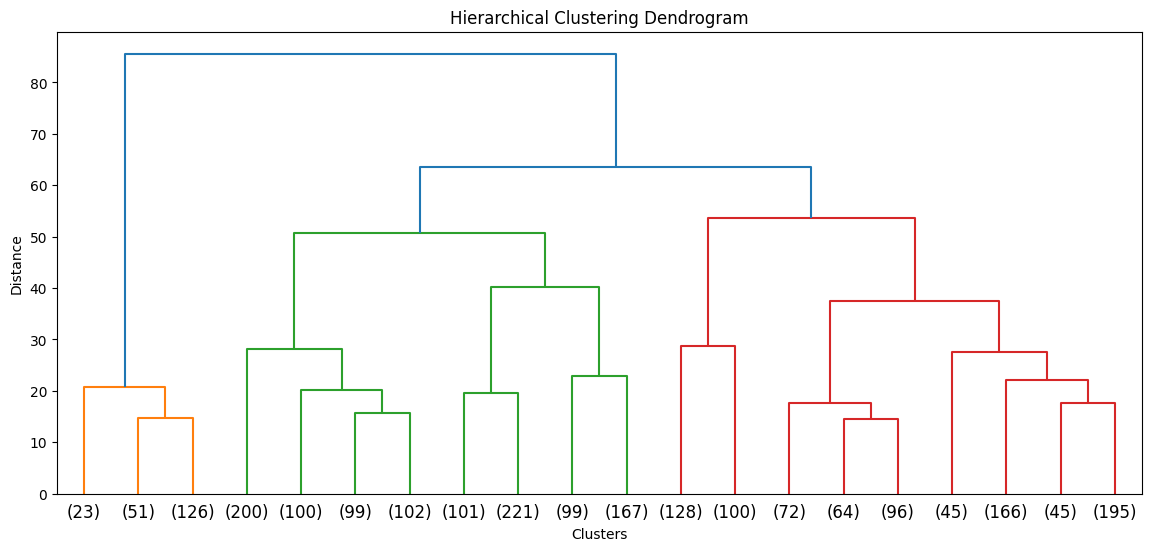

In [37]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(14,6))

dendrogram(
    linked,
    truncate_mode='lastp',
    p=20
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Clusters")
plt.ylabel("Distance")

plt.show()

In [39]:
mask = db_clusters != -1

db_silhouette = silhouette_score(X_scaled[mask], db_clusters[mask])
db_davies = davies_bouldin_score(X_scaled[mask], db_clusters[mask])
db_calinski = calinski_harabasz_score(X_scaled[mask], db_clusters[mask])

print(db_silhouette)
print(db_davies)
print(db_calinski)

0.22899920335558085
0.9286065441296132
288.4481221320182


In [40]:
hc_silhouette = silhouette_score(X_scaled, hc_clusters)
hc_davies = davies_bouldin_score(X_scaled, hc_clusters)
hc_calinski = calinski_harabasz_score(X_scaled, hc_clusters)

print(hc_silhouette)
print(hc_davies)
print(hc_calinski)

0.2592304693088373
1.426909735115703
629.472501911232


In [42]:
results = pd.DataFrame({
    'Algorithm': ['K-Means', 'DBSCAN', 'Hierarchical'],
    'Silhouette Score': [
        0.2553,
        db_silhouette,
        hc_silhouette
    ],
    'Davies-Bouldin Index': [
        1.3866,
        db_davies,
        hc_davies
    ],
    'Calinski-Harabasz Score': [
        658.70,
        db_calinski,
        hc_calinski
    ]
})

results

,Algorithm,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score
0,K-Means,0.255300,1.386600,658.700000
1,DBSCAN,0.228999,0.928607,288.448122
2,Hierarchical,0.259230,1.426910,629.472502


In [43]:
cluster_analysis = pd.crosstab(df['Cluster'], df['label'])

cluster_analysis

label,apple,banana,blackgram,chickpea,coconut,coffee,cotton,grapes,jute,kidneybeans,...,mango,mothbeans,mungbean,muskmelon,orange,papaya,pigeonpeas,pomegranate,rice,watermelon
Cluster,,,,,,,,,,,,,,,,,,,,,
0,0,0,100,100,0,0,0,0,0,100,...,100,100,91,0,0,0,88,0,0,0
1,0,0,0,0,100,47,0,0,99,0,...,0,0,0,0,100,60,12,100,100,0
2,0,100,0,0,0,53,100,0,1,0,...,0,0,9,100,0,40,0,0,0,100
3,100,0,0,0,0,0,0,100,0,0,...,0,0,0,0,0,0,0,0,0,0


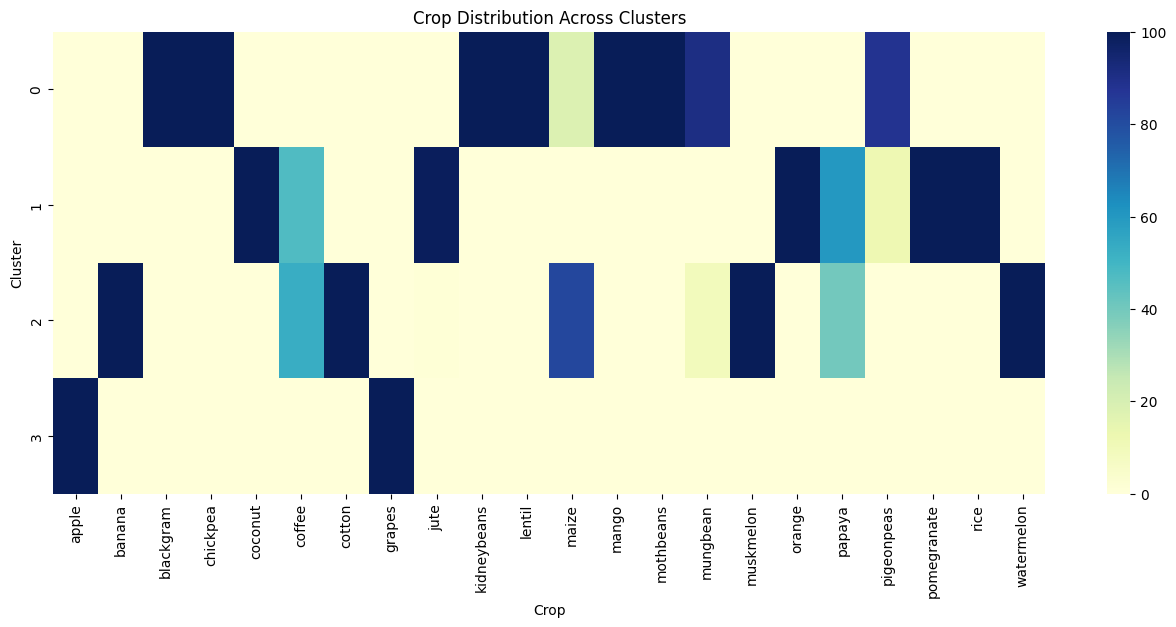

In [44]:
plt.figure(figsize=(16,6))

sns.heatmap(cluster_analysis, cmap='YlGnBu')

plt.title("Crop Distribution Across Clusters")

plt.xlabel("Crop")

plt.ylabel("Cluster")

plt.show()

In [45]:
import joblib

# Save the trained K-Means model
joblib.dump(kmeans, "kmeans_model.pkl")

# Save the scaler
joblib.dump(scaler, "scaler.pkl")

print("Model and Scaler saved successfully!")

Model and Scaler saved successfully!


In [46]:
# Crop distribution in each cluster
cluster_crop_map = pd.crosstab(df['Cluster'], df['label'])

cluster_crop_map

label,apple,banana,blackgram,chickpea,coconut,coffee,cotton,grapes,jute,kidneybeans,...,mango,mothbeans,mungbean,muskmelon,orange,papaya,pigeonpeas,pomegranate,rice,watermelon
Cluster,,,,,,,,,,,,,,,,,,,,,
0,0,0,100,100,0,0,0,0,0,100,...,100,100,91,0,0,0,88,0,0,0
1,0,0,0,0,100,47,0,0,99,0,...,0,0,0,0,100,60,12,100,100,0
2,0,100,0,0,0,53,100,0,1,0,...,0,0,9,100,0,40,0,0,0,100
3,100,0,0,0,0,0,0,100,0,0,...,0,0,0,0,0,0,0,0,0,0


In [47]:
recommendations = {}

for cluster in sorted(df['Cluster'].unique()):
    top_crops = (
        cluster_crop_map.loc[cluster]
        .sort_values(ascending=False)
        .head(5)
        .index
        .tolist()
    )
    recommendations[cluster] = top_crops

recommendations

{np.int32(0): ['chickpea', 'blackgram', 'lentil', 'mango', 'mothbeans'],
 np.int32(1): ['coconut', 'pomegranate', 'rice', 'orange', 'jute'],
 np.int32(2): ['banana', 'cotton', 'muskmelon', 'watermelon', 'maize'],
 np.int32(3): ['apple', 'grapes', 'blackgram', 'chickpea', 'coconut']}

In [48]:
def recommend_crop(N, P, K, temperature, humidity, ph, rainfall):

    # Create DataFrame
    sample = pd.DataFrame([[N, P, K, temperature, humidity, ph, rainfall]],
                          columns=X.columns)

    # Scale input
    sample_scaled = scaler.transform(sample)

    # Predict cluster
    cluster = kmeans.predict(sample_scaled)[0]

    # Display result
    print("="*50)
    print("Predicted Cluster:", cluster)
    print("="*50)

    print("\nRecommended Crops:")

    for crop in recommendations[cluster]:
        print("✔", crop)

    return cluster

In [49]:
recommend_crop(
    N=90,
    P=42,
    K=43,
    temperature=20,
    humidity=82,
    ph=6.5,
    rainfall=200
)

Predicted Cluster: 1

Recommended Crops:
✔ coconut
✔ pomegranate
✔ rice
✔ orange
✔ jute


np.int32(1)

In [50]:
N = float(input("Enter Nitrogen: "))
P = float(input("Enter Phosphorus: "))
K = float(input("Enter Potassium: "))
temperature = float(input("Enter Temperature: "))
humidity = float(input("Enter Humidity: "))
ph = float(input("Enter pH: "))
rainfall = float(input("Enter Rainfall: "))

recommend_crop(N, P, K, temperature, humidity, ph, rainfall)

Enter Nitrogen: 40
Enter Phosphorus: 30
Enter Potassium: 50
Enter Temperature: 30
Enter Humidity: 60
Enter pH: 7
Enter Rainfall: 100
Predicted Cluster: 0

Recommended Crops:
✔ chickpea
✔ blackgram
✔ lentil
✔ mango
✔ mothbeans


np.int32(0)

In [51]:
import joblib
import pandas as pd

# Save model
joblib.dump(kmeans, "kmeans_model.pkl")

# Save scaler
joblib.dump(scaler, "scaler.pkl")

# Create recommendation dictionary
cluster_crop_map = pd.crosstab(df['Cluster'], df['label'])

recommendations = {}

for cluster in sorted(df['Cluster'].unique()):
    recommendations[cluster] = (
        cluster_crop_map.loc[cluster]
        .sort_values(ascending=False)
        .head(5)
        .index
        .tolist()
    )

# Save recommendations
joblib.dump(recommendations, "recommendations.pkl")

print("Everything saved successfully!")

Everything saved successfully!
